Code based in https://ai.google.dev/gemma/docs/core/huggingface_text_finetune_qlora

# Usando QLoRA para fine-tuning Eficiente

Este notebook faz parte do trabalho da disciplina Modelos LLM Embarcados em Dispositivos Móveis. Iremos demonstrar o uso de ajuste-fino eficiente em Large Language Models, aplicando o uso da técnica Quantized Low-Rank Adaptation (QLoRA),que reduz os requisitos computacionais enquanto mantém um alto desempenho. O conjunto de dados utilizado para treinamento será o conjunto BoolQ da Google: um conjunto contendo perguntas e respostas de Verdadeiro ou Falso, contendo 15942 exemplos. Cada exemplo é um trio de (pergunta, passagem, resposta), com o título da página como contexto adicional opcional. O objetivo é melhorar a capacidade de modelos de linguagem em tarefas de Question Answering, muito utilizadas em aplicações como Retrieved Augmentated Generation.

Alunos: \
- Daniel Ambrósio Ferreira Júnior \
- Luana Felipe de Barros \
- Letícia Mayumi Tateishi \
- Fábio Puglia \

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
output_dir = "/content/drive/MyDrive/curso_unicamp_2025/peft_boolq"

In [ ]:
!pip install datasets --quiet
!pip install peft --quiet
!pip install trl --quiet
!pip install bitsandbytes --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 14.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
import numpy as np
import pandas as pd
import os
import sys
import os
from tqdm import tqdm
import json
import torch
sys.path.append(".")
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
from accelerate import Accelerator
from torch.utils.data import DataLoader
from transformers import Trainer
import seaborn as sns
from matplotlib import pyplot as plt
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
import time

import warnings
warnings.filterwarnings("ignore")

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Modelo

In [ ]:
model_name = 'HuggingFaceTB/SmolLM-360M'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/3.69k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

# Conjunto de Dados

In [ ]:
def boolq_format_func(sample):
    sample["Text"] = f"Passage: {sample['passage']} Question: {sample['question']}### Response:\n{str(sample['answer'])}"
    return sample

In [ ]:
dataset = load_dataset("google/boolq")
dataset = dataset.map(lambda x: boolq_format_func(x))
dataset = dataset.map(lambda samples: tokenizer(samples['Text']), batched=True)

data, eval_data = dataset["train"], dataset["validation"]
eval_data = eval_data.shuffle().select(range(min(1000, len(eval_data))))



#preparação do data collator
response_temp = '### Response:\n' #utilizando o mesmo marker
response_temp_ids = tokenizer(response_temp)['input_ids']
data_collator = DataCollatorForCompletionOnlyLM(response_temp_ids, tokenizer = tokenizer)

# training_args = get_trainer_config(path =  f"./output/boolq")
# trainer = SFTTrainer(
#                     model=model,
#                     tokenizer=tokenizer,
#                     args=training_args,
#                     train_dataset=data,
#                     eval_dataset=eval_data,
#                     data_collator=data_collator,
#                     formatting_func=boolq_format_func
#                     )

README.md:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/3.69M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/1.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Map:   0%|          | 0/9427 [00:00<?, ? examples/s]

Map:   0%|          | 0/3270 [00:00<?, ? examples/s]

Map:   0%|          | 0/9427 [00:00<?, ? examples/s]

Map:   0%|          | 0/3270 [00:00<?, ? examples/s]

In [ ]:
eval_data[0]

{'question': 'does the dishwasher make its own hot water',
 'answer': True,
 'passage': "In addition to domestic units, industrial dishwashers are available for use in commercial establishments such as hotels and restaurants, where a large number of dishes must be cleaned. Washing is conducted with temperatures of 65--71 °C (149--160 °F) and sanitation is achieved by either the use of a booster heater that will provide an 82 °C (180 °F) ``final rinse'' temperature or through the use of a chemical sanitizer.",
 'Text': "Passage: In addition to domestic units, industrial dishwashers are available for use in commercial establishments such as hotels and restaurants, where a large number of dishes must be cleaned. Washing is conducted with temperatures of 65--71 °C (149--160 °F) and sanitation is achieved by either the use of a booster heater that will provide an 82 °C (180 °F) ``final rinse'' temperature or through the use of a chemical sanitizer. Question: does the dishwasher make its own

# Treinamento

Inicialmente definiremos o LoRA e os parâmetros de treinamento como anteriormente, aplicados nas camadas de atenção do modelo e com um rank baixo.

In [ ]:
from peft import prepare_model_for_kbit_training

In [ ]:
class QLoRAExperiment:
    def __init__(self, output_dir, model_name, r, max_steps, lora_alpha = 16, lora_dropout=0.05):
        self.r = r
        self.lora_alpha = lora_alpha
        self.lora_dropout = lora_dropout
        self.max_steps = max_steps
        self.output_dir = output_dir
        self.model_name = model_name
        self.config_training()
        self.training_time = 0
        self.peak_memory_usage = 0

    def train(self, train_data, data_collator, eval_data=None):
        self.q_trainer = Trainer(
            model=self.model_q,
            args=self.q_args,
            train_dataset=train_data,
            eval_dataset=eval_data,
            data_collator=data_collator,
            # formatting_func=boolq_format_func
            #peft_config=peft_config,
        )

        start = time.time()
        #model_q.train()
        #model_q.enable_input_require_grads()
        self.q_trainer.train()
        self.training_time = time.time()-start
        self.peak_memory_usage = torch.cuda.max_memory_allocated() / 1024**3
        # print(f"Training time: {self.training_time } seconds")
        # print(f"Peak memory usage: {self.peak} GB")
        self.result =  {
            'r': self.r,
            'lora_alpha': self.lora_alpha,
            'lora_dropout': self.lora_dropout,
            'training_time': self.training_time,
            'peak_memory_usage': self.peak_memory_usage,
            'train_loss': self.q_trainer.state.log_history[-1]['train_loss'],
            'best_step':  self.q_trainer.state.log_history[-1]['step'],
            'eval_loss': self.q_trainer.state.best_metric if eval_data else None
        }
        return self.result

    def load_model(self):
        self.model_q = AutoModelForCausalLM.from_pretrained(self.model_name,
                                                            quantization_config=self.quant_config)
        self.model_q.gradient_checkpointing_enable()
        self.model_q = prepare_model_for_kbit_training(self.model_q)
        self.model_q = get_peft_model(self.model_q, self.peft_config_q)
        self.model_q.print_trainable_parameters()
        self.model_q = self.model_q.to('cuda')

    def config_training(self):
        self.peft_config_q = LoraConfig(
            lora_alpha=self.lora_alpha,
            lora_dropout=self.lora_dropout,
            r=self.r,
            bias="none",
            target_modules=["q_proj", "k_proj", "v_proj"],
            task_type="CAUSAL_LM"
        )

        self.q_args = SFTConfig(
            output_dir=os.path.join(self.output_dir, f'Qlora_r{self.r}'),         # directory to save and repository id
            max_seq_length=512,                     # max sequence length for model and packing of the dataset
            packing=True,                           # Groups multiple samples in the dataset into a single sequence
            max_steps=self.max_steps,                    # max number of training steps
            per_device_train_batch_size=2,          # batch size per device during training
            gradient_accumulation_steps=4,          # number of steps before performing a backward/update pass
            gradient_checkpointing=True,            # use gradient checkpointing to save memory
            optim="paged_adamw_8bit",               # paged adamw optimizer for training
            logging_steps=20,                       # log every 10 steps
            save_strategy="epoch",                  # save checkpoint every epoch
            learning_rate=2e-4,                     # learning rate, based on QLoRA paper
            bf16=True,                              # use bfloat16 precision
            max_grad_norm=0.3,                      # max gradient norm based on QLoRA paper
            warmup_ratio=0.03,                      # warmup ratio based on QLoRA paper
            lr_scheduler_type="constant",           # use constant learning rate scheduler
            dataset_kwargs={
                "add_special_tokens": False, # We template with special tokens
                "append_concat_token": True, # Add EOS token as separator token between examples
            },
            report_to='none',
            dataset_text_field = 'Text',
            evaluation_strategy = 'steps',
            eval_steps = 20
        )

        self.quant_config = BitsAndBytesConfig(
            #load_in_8bit=True,
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_quant_storage=torch.bfloat16
        )
        self.load_model()

        pass

In [ ]:
experiments = []
rs = [2, 4, 8, 12]
for r in rs:
    experiment = QLoRAExperiment(output_dir, model_name, r, max_steps=80)
    result = experiment.train(data, data_collator, eval_data)  # Inclua eval_data se disponível
    experiments.append(experiment)

`low_cpu_mem_usage` was None, now default to True since model is quantized.
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


trainable params: 286,720 || all params: 362,107,840 || trainable%: 0.0792


Step,Training Loss,Validation Loss
20,6.394600,4.612836
40,2.728200,1.009927
60,0.773300,0.683223
80,0.742800,0.855803


`low_cpu_mem_usage` was None, now default to True since model is quantized.
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


trainable params: 573,440 || all params: 362,394,560 || trainable%: 0.1582


...

trainable params: 1,146,880 || all params: 362,968,000 || trainable%: 0.3160


Step,Training Loss,Validation Loss
20,6.385300,4.587749
40,2.693100,0.989592
60,0.768700,0.675987
80,0.731200,0.828900


`low_cpu_mem_usage` was None, now default to True since model is quantized.
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


trainable params: 1,720,320 || all params: 363,541,440 || trainable%: 0.4732


Step,Training Loss,Validation Loss
20,6.370400,4.561340
40,2.666000,0.975223
60,0.771500,0.673759
80,0.734500,0.822481


In [ ]:
experiments[0].q_trainer.state.log_history

[{'loss': 6.3946,
  'grad_norm': 7.7319560050964355,
  'learning_rate': 0.0002,
  'epoch': 0.01697072549851506,
  'step': 20},
 {'eval_loss': 4.612835884094238,
  'eval_runtime': 103.5843,
  'eval_samples_per_second': 9.654,
  'eval_steps_per_second': 1.207,
  'epoch': 0.01697072549851506,
  'step': 20},
 {'loss': 2.7282,
  'grad_norm': 4.271040439605713,
  'learning_rate': 0.0002,
  'epoch': 0.03394145099703012,
  'step': 40},
 {'eval_loss': 1.009926676750183,
  'eval_runtime': 103.5941,
  'eval_samples_per_second': 9.653,
  'eval_steps_per_second': 1.207,
  'epoch': 0.03394145099703012,
  'step': 40},
 {'loss': 0.7733,
  'grad_norm': 2.84135365486145,
  'learning_rate': 0.0002,
  'epoch': 0.050912176495545185,
  'step': 60},
 {'eval_loss': 0.6832231283187866,
  'eval_runtime': 103.8966,
  'eval_samples_per_second': 9.625,
  'eval_steps_per_second': 1.203,
  'epoch': 0.050912176495545185,
  'step': 60},
 {'loss': 0.7428,
  'grad_norm': 9.002277374267578,
  'learning_rate': 0.0002,
  '

In [ ]:
import numpy as np
import re
import io
from contextlib import redirect_stdout

def plot_experiment_results(experiments):
    # Gráfico 1: Relação entre r, parâmetros treináveis e média da loss
    df_summary = pd.DataFrame([{
        "r": exp.r,
        "train_loss": exp.result['train_loss'],
        "eval_loss": exp.result['eval_loss'],
    } for exp in experiments])
    parameters = []
    for model in experiments:
        output_buffer = io.StringIO()
        with redirect_stdout(output_buffer):
          model.model_q.print_trainable_parameters()
        captured_output = output_buffer.getvalue()
        output_buffer.close()
        match = re.search(r'trainable params: ([\d,]+)', captured_output)
        if match:
            captured_output = int(match.group(1).replace(',', ''))
            # print(captured_output)
            parameters.append(captured_output)

    fig, ax1 = plt.subplots()
    ax1.set_xlabel('Rank (r)')
    ax1.set_ylabel('Parâmetros Treináveis', color='tab:blue')
    ax1.plot(df_summary['r'], parameters, marker='o', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    plt.title('Efeito do Rank (r) no Tamanho do Modelo')
    plt.show()

    # GRÁFICO 2: RANK X LOSS
    plt.figure(figsize=(10, 5))

    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D']

    for i, experiment in enumerate(experiments):
        log_history = experiment.q_trainer.state.log_history
        train_loss = []
        eval_loss = []
        steps = []

        for log_entry in log_history:
            if 'loss' in log_entry:
                train_loss.append(log_entry['loss'])
                steps.append(log_entry['step'])
            if 'eval_loss' in log_entry:
                eval_loss.append(log_entry['eval_loss'])

        plt.plot(steps, train_loss, label=f"Training Loss (r={experiment.r})",
                 linestyle=line_styles[i % len(line_styles)], marker=markers[i % len(markers)])
        if eval_loss:
            plt.plot(steps, eval_loss, label=f"Evaluation Loss (r={experiment.r})",
                 linestyle=line_styles[i % len(line_styles)], marker=markers[i % len(markers)])

    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Loss de Treino e validação durante o treinamento (Para cada r)')
    plt.legend()
    # plt.yscale('log')  # Use logarithmic scale if needed
    # plt.ylim(bottom=0.3)  # Set minimum y-axis limit

    plt.show()

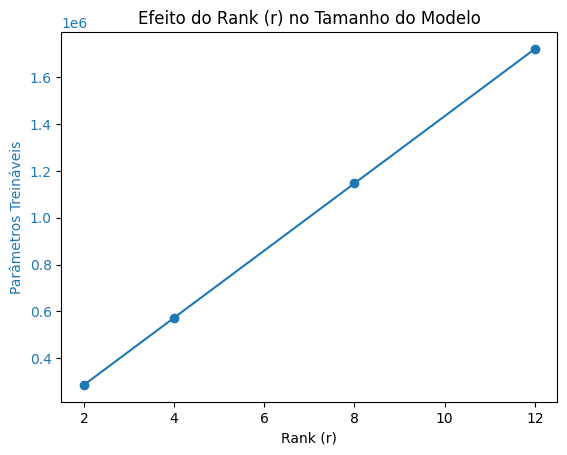

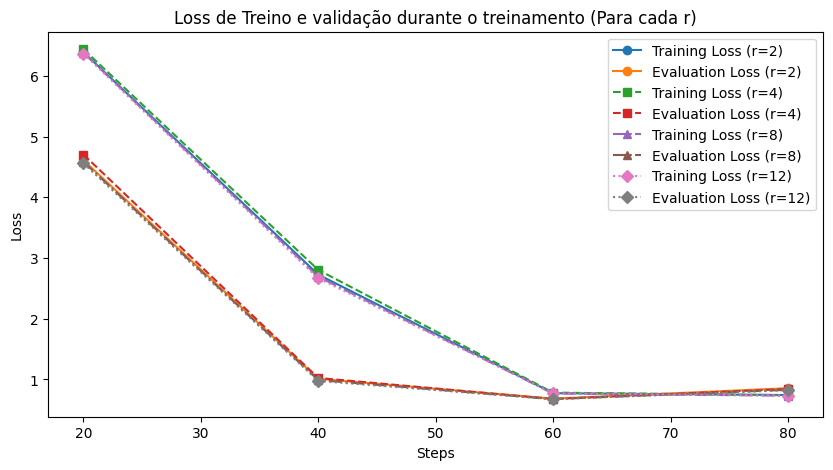

In [ ]:
plot_experiment_results(experiments)

In [ ]:
def model_inference(model, tokenizer, prompt, max_new_tokens=100):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=False,
        )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response

# Teste

In [ ]:
x = f"""Passage: Harry Potter and the Escape from Gringotts is an indoor steel roller coaster at Universal Studios Florida, a theme park located within the Universal Orlando Resort. Similar to dark rides, the roller coaster utilizes special effects in a controlled-lighting environment and also employs motion-based 3-D projection of both animation and live-action sequences to enhance the experience. The ride, which is themed to the Gringotts Wizarding Bank, became the flagship attraction for the expanded Wizarding World of Harry Potter when it opened on July 8, 2014.
Question: is harry potter and the escape from gringotts a roller coaster ride
### Response:\n"""


In [ ]:
from IPython.display import Markdown

Markdown(x)

Passage: Harry Potter and the Escape from Gringotts is an indoor steel roller coaster at Universal Studios Florida, a theme park located within the Universal Orlando Resort. Similar to dark rides, the roller coaster utilizes special effects in a controlled-lighting environment and also employs motion-based 3-D projection of both animation and live-action sequences to enhance the experience. The ride, which is themed to the Gringotts Wizarding Bank, became the flagship attraction for the expanded Wizarding World of Harry Potter when it opened on July 8, 2014.
Question: is harry potter and the escape from gringotts a roller coaster ride
### Response:


In [ ]:
non_finetuned_model = AutoModelForCausalLM.from_pretrained(model_name)
non_finetuned_model.to('cuda')
model_inference(non_finetuned_model, tokenizer, x)

'Passage: Harry Potter and the Escape from Gringotts is an indoor steel roller coaster at Universal Studios Florida, a theme park located within the Universal Orlando Resort. Similar to dark rides, the roller coaster utilizes special effects in a controlled-lighting environment and also employs motion-based 3-D projection of both animation and live-action sequences to enhance the experience. The ride, which is themed to the Gringotts Wizarding Bank, became the flagship attraction for the expanded Wizarding World of Harry Potter when it opened on July 8, 2014.\nQuestion: is harry potter and the escape from gringotts a roller coaster ride\n### Response:\n\n### Harry Potter and the Escape from Gringotts\n\nHarry Potter and the Escape from Gringotts is an indoor steel roller coaster at Universal Studios Florida, a theme park located within the Universal Orlando Resort. Similar to dark rides, the roller coaster utilizes special effects in a controlled-lighting environment and also employs m

In [ ]:
for experiment in experiments:
    response = model_inference(experiment.model_q, tokenizer, x)
    print(f"\n\nr: {experiment.r}\nResposta: {response}")



r: 2
Resposta: Passage: Harry Potter and the Escape from Gringotts is an indoor steel roller coaster at Universal Studios Florida, a theme park located within the Universal Orlando Resort. Similar to dark rides, the roller coaster utilizes special effects in a controlled-lighting environment and also employs motion-based 3-D projection of both animation and live-action sequences to enhance the experience. The ride, which is themed to the Gringotts Wizarding Bank, became the flagship attraction for the expanded Wizarding World of Harry Potter when it opened on July 8, 2014.
Question: is harry potter and the escape from gringotts a roller coaster ride
### Response:
False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False False Fa

# Conclusão


Ao analisar diferentes tamanhos de rank, podemos ver que, aumentar ou diminuir o número de parâmetros da rede convergiu para um resultado parecido no fine-tuning da rede, em termos de Loss de treino e validação, como também em tempo de convergência.
Além disso, vemos que os modelos finetunados foram muito mais ajustados para a tarefa de perguntas e respostas, do que o modelo original.

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()